In [17]:
feature_order = [
    # 'epoch', 'train_size',

    # old
    # 'loss_start', 'loss_mid',
    'loss_last_1', 'loss_last_2',
    # 'loss_growth', 'loss_stability',

    # gap
    # 'gap_last', 'gap_growth', 'gap_std',

    # global
    # 'best_loss',
    'epochs_since_best',
    'global_slope', 'global_curvature',
    # 'distance_from_best',

    # recent
    'recent_slope', 'recent_improvement',

    'acc_norm', 'distance_norm'
]

In [19]:
import pandas as pd
import numpy as np
import ast

from keras.src.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/final.csv", sep=';')

# строки -> списки
df['val_loss'] = df['val_loss'].map(ast.literal_eval)
df['train_loss'] = df['train_loss'].map(ast.literal_eval)

# flatten если вложенные списки
df['val_loss'] = df['val_loss'].map(lambda l: [v[0] if isinstance(v, list) else v for v in l])
df['train_loss'] = df['train_loss'].map(lambda l: [v[0] if isinstance(v, list) else v for v in l])

# фильтр
df = df[df['val_loss'].apply(lambda x: len(x) > 4)]
df = df[df['shift_type'].isin(['none', 'noise'])]
# -------- LOSS FEATURES --------

df["loss_start"] = df["val_loss"].apply(lambda x: x[0])
df["loss_mid"] = df["val_loss"].apply(lambda x: x[len(x) // 2])
df["loss_last_1"] = df["val_loss"].apply(lambda x: x[-2] / x[0])
df["loss_last_2"] = df["val_loss"].apply(lambda x: x[-3] / x[0])
df['acc_norm'] =  df["val_loss"].apply(
    lambda c: ((c[-2] - c[-3]) - (c[-3] - c[-4])) / (c[-3] + 1e-8)
)
df["epoch"] = df["val_loss"].apply(len)
df["loss_end"] = df["val_loss"].apply(lambda x: x[-1])
df["loss_growth"] = df["loss_end"] - df["loss_start"]
df["loss_stability"] = df["val_loss"].apply(lambda x: np.std(x[:-1]))

df['distance_norm'] = df['val_loss'].apply(lambda x: (x[-2] - min(x[:-1])) / (x[0] - min(x[:-1]) + 1e-8))
# -------- GLOBAL CONTEXT FEATURES --------

def build_global_features(val_loss):
    val = np.array(val_loss)
    n = len(val)

    x = np.arange(n)

    # --- глобальный тренд ---
    slope = np.polyfit(x, val, 1)[0] if n > 1 else 0

    # --- кривизна (ускорение тренда) ---
    curvature = np.polyfit(x, val, 2)[0] if n > 2 else 0

    # --- лучший момент ---
    best_idx = np.argmin(val)
    best_loss = val[best_idx]

    # --- текущая позиция ---
    current_loss = val[-1]

    return pd.Series({
        "global_slope": slope,
        "global_curvature": curvature,

        "best_loss": best_loss,
        "distance_from_best": current_loss - best_loss,
        "epochs_since_best": n - best_idx,
    })


global_df = df["val_loss"].apply(build_global_features)
df = pd.concat([df, global_df], axis=1)


# -------- LOCAL (RECENT) FEATURES --------

def build_recent_features(val_loss, window=5):
    val = np.array(val_loss)
    n = len(val)

    if n < 2:
        return pd.Series({
            "recent_slope": 0,
            "recent_improvement": 0
        })

    val_recent = val[-window:] if n >= window else val
    x = np.arange(len(val_recent))

    slope = np.polyfit(x, val_recent, 1)[0] if len(val_recent) > 1 else 0

    improvement = val_recent[0] - val_recent[-1]

    return pd.Series({
        "recent_slope": slope,
        "recent_improvement": improvement
    })


recent_df = df["val_loss"].apply(build_recent_features)
df = pd.concat([df, recent_df], axis=1)


# -------- CLEAN --------
train_delta = (df["loss_end"] - df["loss_last_1"]) / df["loss_last_1"]
threshold = 0.5 * np.std(train_delta)
df['imbalance'] = df['imbalance'].astype(int)

# df = df.drop(columns=[
#     "val_loss",
#     "train_loss",
#     "val_acc",
#     "index",
#     "seed"
# ])

# -------- FEATURES --------

X = df[feature_order]
y = df["val_loss"].apply(lambda x: (x[-1] - x[-2]) / (x[-2] + 1e-8))
# y = y / np.std(y)
print(df.describe())
print(y.describe())
X = X.dropna()
y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

             index        epoch     test_acc  overfitting   train_size  \
count  3696.000000  3696.000000  3696.000000  3696.000000  3696.000000   
mean   2098.242424    34.793290     0.753080     0.500000  1264.285714   
std    1202.835262    23.561086     0.156870     0.500068  1652.649140   
min       0.000000     6.000000     0.097500     0.000000    50.000000   
25%     993.250000    21.000000     0.639775     0.000000   100.000000   
50%    2211.500000    28.000000     0.769250     0.500000   500.000000   
75%    3135.250000    40.000000     0.889625     1.000000  2000.000000   
max    4059.000000   210.000000     0.982500     1.000000  5000.000000   

              seed    imbalance   loss_start     loss_mid  loss_last_1  ...  \
count  3696.000000  3696.000000  3696.000000  3696.000000  3696.000000  ...   
mean      6.106061     0.500000     1.600830     0.721397     0.430032  ...   
std       3.810903     0.500068     0.706650     0.507957     0.176769  ...   
min       0.00000

In [20]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# model = RandomForestRegressor(
#     n_estimators=300,
#     random_state=42,
#     n_jobs=-1
# )
model = XGBRegressor()

model.fit(X_train, y_train)
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.019165702207436738
RMSE: 0.041345589388898596
R2: 0.30769462946235426


In [21]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers

normalizer = layers.Normalization()
normalizer.adapt(X_train.to_numpy())
# --- модель ---
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),  # количество признаков
    normalizer,
    layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(32, activation='relu'),

    layers.Dense(1),
])

# --- компиляция ---
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="mse",
    metrics=["mae"]
)

# --- обучение ---
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

# --- предсказание ---
pred = model.predict(X_test).flatten()

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Epoch 1/100


D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4198 - mae: 0.4851 - val_loss: 0.0409 - val_mae: 0.1533
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2678 - mae: 0.3868 - val_loss: 0.0681 - val_mae: 0.2124
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2368 - mae: 0.3590 - val_loss: 0.0827 - val_mae: 0.2305
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1977 - mae: 0.3346 - val_loss: 0.0762 - val_mae: 0.2088
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1847 - mae: 0.3145 - val_loss: 0.0630 - val_mae: 0.1809
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1652 - mae: 0.2966 - val_loss: 0.0555 - val_mae: 0.1650
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1455 - mae: 0.2814 - val_loss: 0.0525 - val_mae: 0.1532
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1383 - mae: 0.2771 - val_loss: 0.0481 - val_mae: 0.1483
Epoch 9/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1192 - mae: 0.2

In [22]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np


def benchmark_regressors(models, X_train, X_test, y_train, y_test):
    results = []

    for name, model in models.items():
        # обучение
        model.fit(X_train, y_train)

        # предсказание
        pred = model.predict(X_test)

        # метрики
        r2 = r2_score(y_test, pred)
        mae = mean_absolute_error(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))

        results.append({
            "model": name,
            "R2": r2,
            "MAE": mae,
            "RMSE": rmse,
            "mm": model
        })

    results_df = pd.DataFrame(results)
    return results_df.sort_values("R2", ascending=False)

In [23]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor,
    HistGradientBoostingRegressor
)

models = {

    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),

    "DecisionTree": DecisionTreeRegressor(),

    "RandomForest": RandomForestRegressor(n_estimators=200),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=200),

    "GradientBoosting": GradientBoostingRegressor(),
    "HistGradientBoosting": HistGradientBoostingRegressor(),

    "AdaBoost": AdaBoostRegressor(),

    "KNN": KNeighborsRegressor(n_neighbors=5),

    "SVR": SVR(),

    "MLP": MLPRegressor(max_iter=500)
}

results = benchmark_regressors(
    models,
    X_train,
    X_test,
    y_train,
    y_test
)

print(results)

                   model         R2       MAE      RMSE  \
3           RandomForest   0.542952  0.016888  0.033594   
6   HistGradientBoosting   0.514117  0.018173  0.034637   
4             ExtraTrees   0.506227  0.017229  0.034918   
5       GradientBoosting   0.488855  0.019223  0.035527   
0       LinearRegression   0.382776  0.020006  0.039039   
1                  Ridge   0.299096  0.022280  0.041602   
8                    KNN   0.234841  0.021686  0.043467   
2           DecisionTree   0.110084  0.024778  0.046876   
9                    SVR  -0.006370  0.025348  0.049849   
7               AdaBoost  -0.684075  0.050278  0.064485   
10                   MLP -50.082796  0.051647  0.355155   

                                                   mm  
3   (DecisionTreeRegressor(max_features=1.0, rando...  
6                     HistGradientBoostingRegressor()  
4   (ExtraTreeRegressor(random_state=426939780), E...  
5   ([DecisionTreeRegressor(criterion='friedman_ms...  
0          

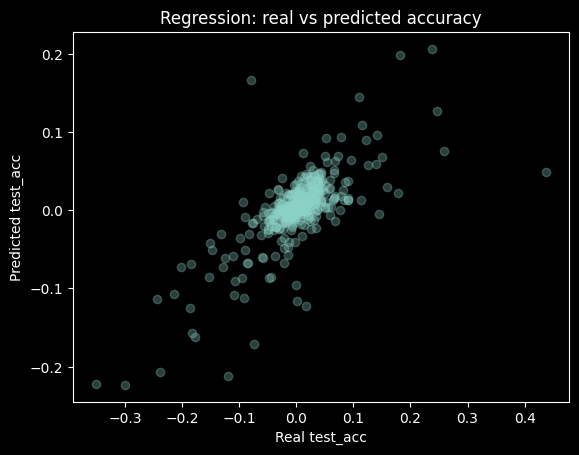

In [24]:
import matplotlib.pyplot as plt

pred = results.iloc[0]["mm"].predict(X_test)

plt.scatter(y_test, pred, alpha=0.3)

plt.xlabel("Real test_acc")
plt.ylabel("Predicted test_acc")
plt.title("Regression: real vs predicted accuracy")

# plt.plot([0,1],[0,1])
plt.show()

acc_norm              0.344005
distance_norm         0.163795
recent_improvement    0.159309
recent_slope          0.088334
global_slope          0.064121
loss_last_1           0.051214
loss_last_2           0.049038
global_curvature      0.047476
epochs_since_best     0.032708
dtype: float64


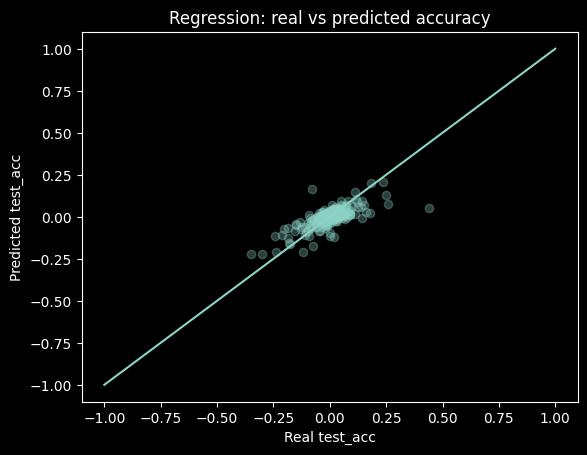

In [25]:
model_reg = RandomForestRegressor()
model_reg.fit(X_train, y_train)

importance = pd.Series(
    model_reg.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)
model_reg = results.iloc[0]["mm"]
import matplotlib.pyplot as plt

pred = model_reg.predict(X_test)

plt.scatter(y_test, pred, alpha=0.3)

plt.xlabel("Real test_acc")
plt.ylabel("Predicted test_acc")
plt.title("Regression: real vs predicted accuracy")

plt.plot([-1, 1], [-1, 1])
plt.show()

In [26]:
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import Callback


class SmartEarlyStoppingMultiStep(Callback):
    def __init__(
        self,
        model_meta,
        train_size,
        future_steps=3,
        min_epochs=5,
        threshold_increase=1e-3,
    ):
        super().__init__()
        self.should_stop = False
        self.model_meta = model_meta
        self.train_size = train_size
        self.future_steps = future_steps
        self.min_epochs = min_epochs
        self.threshold_increase = threshold_increase

        self.train_loss = []
        self.val_loss = []



    def on_epoch_end(self, epoch, logs=None):
        train_loss = logs.get("loss")
        val_loss = logs.get("val_loss")

        if train_loss is None or val_loss is None:
            return

        self.train_loss.append(train_loss)
        self.val_loss.append(val_loss)

        if len(self.val_loss) < self.min_epochs:
            return

        preds = self.predict_future(epoch)

        trend = np.polyfit(range(len(preds)), preds, 1)[0]

        if trend > 0:
            print(f"Expected future increase → stopping at epoch {epoch}")
            self.model.stop_training = True
            self.should_stop = True

        print(
            f"epoch={epoch} val_loss={val_loss:.4f} "
            f"future={[round(x, 4) for x in preds]} trend={trend:.6f}"
        )

    # --- core ---
    def predict_future(self, epoch):
        val = list(self.val_loss)
        train = list(self.train_loss)

        preds = []

        for step in range(self.future_steps):

            val_np = np.array(val)
            train_np = np.array(train)
            min_len_np = len(val_np)
            # --- safety ---
            if min_len_np < 5:
                val_np = np.pad(val_np, (5 - min_len_np, 0), "edge")
                train_np = np.pad(train_np, (5 - min_len_np, 0), "edge")

            # gap = train_np - val_np

            # --- last values (safe) ---
            def safe_idx(arr, i):
                return arr[i] if len(arr) > abs(i) else arr[0]

            # --- global features ---
            x_full = np.arange(min_len_np)

            global_slope = np.polyfit(x_full, val_np, 1)[0] if min_len_np > 1 else 0
            global_curvature = np.polyfit(x_full, val_np, 2)[0] if min_len_np > 2 else 0

            best_idx = np.argmin(val_np)
            best_loss = val_np[best_idx]

            # --- recent ---
            window = 5
            val_recent = val_np[-window:] if min_len_np >= window else val_np
            x_recent = np.arange(len(val_recent))

            recent_slope = np.polyfit(x_recent, val_recent, 1)[0] if len(val_recent) > 1 else 0
            recent_improvement = val_recent[0] - val_recent[-1]

            row = {
                "train_size": self.train_size,
                "epoch": epoch + step,

                # --- base ---
                "loss_start": val_np[0],
                "loss_mid": val_np[min_len_np//2],
                "loss_last_1": safe_idx(val_np, -1) / val_np[0],
                "loss_last_2": safe_idx(val_np, -2) / val_np[0],
                "loss_last_3": safe_idx(val_np, -3) / val_np[0],

                "loss_acceleration": (safe_idx(val_np, -1) - 2 * safe_idx(val_np, -2) + safe_idx(val_np, -3)),
                "loss_growth": val_np[-1] - val_np[0],
                "loss_stability": np.std(val_np),

                # --- gap ---
                # "gap_last": gap[-1],
                # "gap_growth": gap[-1] - gap[0],
                # "gap_std": np.std(gap),

                # --- global ---
                "best_loss": best_loss,
                "epochs_since_best": min_len_np - best_idx,
                "global_slope": global_slope,
                "global_curvature": global_curvature,
                "distance_from_best": val_np[-1] - best_loss,
                "progress_ratio": min_len_np / 100.0,

                # --- recent ---
                "recent_slope": recent_slope,
                "recent_improvement": recent_improvement,
                "acc_norm": (safe_idx(val_np, -1) - 2 * safe_idx(val_np, -2) + safe_idx(val_np, -3)) / val_np[0],
                "distance_norm":  (safe_idx(val_np, -1) - min(val_np)) / (val_np[0] - min(val_np) + 1e-8),
            }

            df = pd.DataFrame([row])[feature_order]

            pred_delta = self.model_meta.predict(df)[0]

            next_val = val[-1] * (1 + pred_delta)
            preds.append(next_val)

            val.append(next_val)

        return preds

In [33]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)


def build_mlp(hidden_units=128, l2=0.0):
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(hidden_units, activation="relu",
                     kernel_regularizer=regularizers.l2(l2)),
        layers.Dropout(0.3),
        layers.Dense(10, activation="softmax")
    ])
    return model


def build_mlp_overfit():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),  # вход
        layers.Dense(32, activation="relu"),     # первый скрытый слой
        # layers.Dense(212, activation="relu"),     # второй скрытый слой
        # layers.Dense(256, activation="relu"),     # третий скрытый слой
        # Сильно уменьшаем Dropout или убираем его
        layers.Dropout(0.05),
        layers.Dense(10, activation="softmax")  # выходной слой
    ])
    return model

In [34]:
smart_stop = SmartEarlyStoppingMultiStep(
    model_reg,
    2000, threshold_increase=threshold * 0.5
)
model_mnist = build_mlp_overfit()
model_mnist.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


model_mnist.fit(
    X_train[:2000],
    y_train[:2000],

    validation_split=0.2,
    epochs=200,
    batch_size=10,
    # callbacks=[EarlyStopping(verbose=1, patience=5)]
    # callbacks=[smart_stop]

    callbacks=[smart_stop], verbose=0,
)



D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


epoch=4 val_loss=0.2890 future=[np.float64(0.2783), np.float64(0.2727), np.float64(0.268)] trend=-0.005144
epoch=5 val_loss=0.2826 future=[np.float64(0.277), np.float64(0.2721), np.float64(0.2678)] trend=-0.004636
epoch=6 val_loss=0.2668 future=[np.float64(0.2594), np.float64(0.2568), np.float64(0.2552)] trend=-0.002124
epoch=7 val_loss=0.2586 future=[np.float64(0.256), np.float64(0.2545), np.float64(0.2538)] trend=-0.001073
epoch=8 val_loss=0.2638 future=[np.float64(0.2667), np.float64(0.2664), np.float64(0.2656)] trend=-0.000551
epoch=9 val_loss=0.2753 future=[np.float64(0.2738), np.float64(0.2724), np.float64(0.2732)] trend=-0.000304
Expected future increase → stopping at epoch 10
epoch=10 val_loss=0.2703 future=[np.float64(0.2701), np.float64(0.2722), np.float64(0.2751)] trend=0.002487


In [29]:
from tensorflow.keras.callbacks import EarlyStopping


def run_training(X, y, train_size, callback):
    model = build_mlp_overfit()

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X[:train_size],
        y[:train_size],
        validation_split=0.2,
        epochs=200,
        batch_size=16,
        verbose=0,
        callbacks=[callback]
    )

    epochs = len(history.history["loss"])

    # качество на тесте
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    best_val_loss = min(history.history["val_loss"])

    return {
        "epochs": epochs,
        "test_acc": test_acc,
        "test_loss": test_loss,
        "best_val_loss": best_val_loss
    }

In [30]:
sizes = [500, 1000, 2000, 5000]
runs = 4

results = []

for size in sizes:

    for r in range(runs):
        early = EarlyStopping(
            monitor="val_loss",
            patience=5
        )

        smart = SmartEarlyStoppingMultiStep(
            model_reg,
            size
        )

        res_early = run_training(X_train, y_train, size, early)
        res_smart = run_training(X_train, y_train, size, smart)

        results.append({
            "train_size": size,
            "run": r,

            "early_epochs": res_early["epochs"],
            "early_acc": res_early["test_acc"],
            "early_loss": res_early["test_loss"],

            "smart_epochs": res_smart["epochs"],
            "smart_acc": res_smart["test_acc"],
            "smart_loss": res_smart["test_loss"],
        })

df = pd.DataFrame(results)

D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


epoch=4 val_loss=0.8418 future=[np.float64(0.7975), np.float64(0.7647), np.float64(0.7489)] trend=-0.024319
epoch=5 val_loss=0.7708 future=[np.float64(0.7312), np.float64(0.7123), np.float64(0.6966)] trend=-0.017288
epoch=6 val_loss=0.7304 future=[np.float64(0.7103), np.float64(0.6946), np.float64(0.6791)] trend=-0.015583
epoch=7 val_loss=0.6934 future=[np.float64(0.6784), np.float64(0.663), np.float64(0.6479)] trend=-0.015229
epoch=8 val_loss=0.6684 future=[np.float64(0.6532), np.float64(0.6383), np.float64(0.6234)] trend=-0.014904
epoch=9 val_loss=0.6434 future=[np.float64(0.6288), np.float64(0.6142), np.float64(0.6036)] trend=-0.012570
epoch=10 val_loss=0.6248 future=[np.float64(0.6106), np.float64(0.5986), np.float64(0.5948)] trend=-0.007873
epoch=11 val_loss=0.6088 future=[np.float64(0.596), np.float64(0.5881), np.float64(0.5849)] trend=-0.005535
epoch=12 val_loss=0.6007 future=[np.float64(0.5976), np.float64(0.593), np.float64(0.5907)] trend=-0.003422
epoch=13 val_loss=0.5907 fut

D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


epoch=4 val_loss=0.8825 future=[np.float64(0.8368), np.float64(0.7933), np.float64(0.7711)] trend=-0.032818
epoch=5 val_loss=0.8108 future=[np.float64(0.7661), np.float64(0.7409), np.float64(0.7243)] trend=-0.020895
epoch=6 val_loss=0.7586 future=[np.float64(0.7323), np.float64(0.7157), np.float64(0.6997)] trend=-0.016262
epoch=7 val_loss=0.7177 future=[np.float64(0.7012), np.float64(0.6857), np.float64(0.6701)] trend=-0.015547
epoch=8 val_loss=0.6903 future=[np.float64(0.6749), np.float64(0.6594), np.float64(0.6442)] trend=-0.015361
epoch=9 val_loss=0.6671 future=[np.float64(0.652), np.float64(0.6376), np.float64(0.6245)] trend=-0.013784
epoch=10 val_loss=0.6480 future=[np.float64(0.6335), np.float64(0.618), np.float64(0.6124)] trend=-0.010586
epoch=11 val_loss=0.6277 future=[np.float64(0.6127), np.float64(0.6027), np.float64(0.5982)] trend=-0.007252
epoch=12 val_loss=0.6150 future=[np.float64(0.6053), np.float64(0.6007), np.float64(0.596)] trend=-0.004652
epoch=13 val_loss=0.6061 fut

D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

epoch=4 val_loss=0.3647 future=[np.float64(0.3588), np.float64(0.3532), np.float64(0.3507)] trend=-0.004021
epoch=5 val_loss=0.3572 future=[np.float64(0.3517), np.float64(0.3497), np.float64(0.3482)] trend=-0.001718
epoch=6 val_loss=0.3504 future=[np.float64(0.348), np.float64(0.3463), np.float64(0.3446)] trend=-0.001685
epoch=7 val_loss=0.3406 future=[np.float64(0.3372), np.float64(0.335), np.float64(0.3336)] trend=-0.001825
epoch=8 val_loss=0.3368 future=[np.float64(0.3346), np.float64(0.3331), np.float64(0.3319)] trend=-0.001322
epoch=9 val_loss=0.3262 future=[np.float64(0.3241), np.float64(0.3226), np.float64(0.3212)] trend=-0.001430
epoch=10 val_loss=0.3251 future=[np.float64(0.3236), np.float64(0.3224), np.float64(0.3214)] trend=-0.001098
epoch=11 val_loss=0.3211 future=[np.float64(0.3199), np.float64(0.3182), np.float64(0.3177)] trend=-0.001085
epoch=12 val_loss=0.3253 future=[np.float64(0.3261), np.float64(0.3249), np.float64(0.3244)] trend=-0.000852
epoch=13 val_loss=0.3179 fu

D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


epoch=4 val_loss=0.3708 future=[np.float64(0.3646), np.float64(0.3589), np.float64(0.3559)] trend=-0.004381
epoch=5 val_loss=0.3602 future=[np.float64(0.3545), np.float64(0.3525), np.float64(0.3494)] trend=-0.002552
epoch=6 val_loss=0.3444 future=[np.float64(0.3419), np.float64(0.3405), np.float64(0.3387)] trend=-0.001602
epoch=7 val_loss=0.3396 future=[np.float64(0.3381), np.float64(0.3358), np.float64(0.3341)] trend=-0.001987
epoch=8 val_loss=0.3372 future=[np.float64(0.335), np.float64(0.3333), np.float64(0.3325)] trend=-0.001273
epoch=9 val_loss=0.3278 future=[np.float64(0.3255), np.float64(0.3243), np.float64(0.3229)] trend=-0.001312
Expected future increase → stopping at epoch 10
epoch=10 val_loss=0.3303 future=[np.float64(0.3375), np.float64(0.3384), np.float64(0.3377)] trend=0.000068


D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


epoch=4 val_loss=0.3729 future=[np.float64(0.3667), np.float64(0.3612), np.float64(0.3586)] trend=-0.004072
epoch=5 val_loss=0.3632 future=[np.float64(0.3574), np.float64(0.3553), np.float64(0.3536)] trend=-0.001878
epoch=6 val_loss=0.3488 future=[np.float64(0.3454), np.float64(0.3426), np.float64(0.3407)] trend=-0.002371
epoch=7 val_loss=0.3477 future=[np.float64(0.3451), np.float64(0.343), np.float64(0.3413)] trend=-0.001886
epoch=8 val_loss=0.3357 future=[np.float64(0.3309), np.float64(0.329), np.float64(0.3278)] trend=-0.001503
epoch=9 val_loss=0.3331 future=[np.float64(0.3315), np.float64(0.3303), np.float64(0.3285)] trend=-0.001514
epoch=10 val_loss=0.3308 future=[np.float64(0.3294), np.float64(0.3282), np.float64(0.3278)] trend=-0.000788
epoch=11 val_loss=0.3257 future=[np.float64(0.3244), np.float64(0.3236), np.float64(0.3233)] trend=-0.000517
epoch=12 val_loss=0.3296 future=[np.float64(0.329), np.float64(0.3283), np.float64(0.328)] trend=-0.000476
epoch=13 val_loss=0.3256 futu

            early_acc  smart_acc  early_loss  smart_loss  early_epochs  \
train_size                                                               
500          0.815650   0.807500    0.612996    0.632546         43.75   
1000         0.865825   0.863400    0.443916    0.460688         28.00   
2000         0.882550   0.882425    0.413050    0.408330         41.50   
5000         0.902875   0.903300    0.334540    0.333031         22.75   

            smart_epochs  diff_epochs  diff_acc  diff_loss  
train_size                                                  
500                21.50        22.25  0.008150  -0.019551  
1000               19.50         8.50  0.002425  -0.016772  
2000               14.25        27.25  0.000125   0.004720  
5000               13.75         9.00 -0.000425   0.001508  


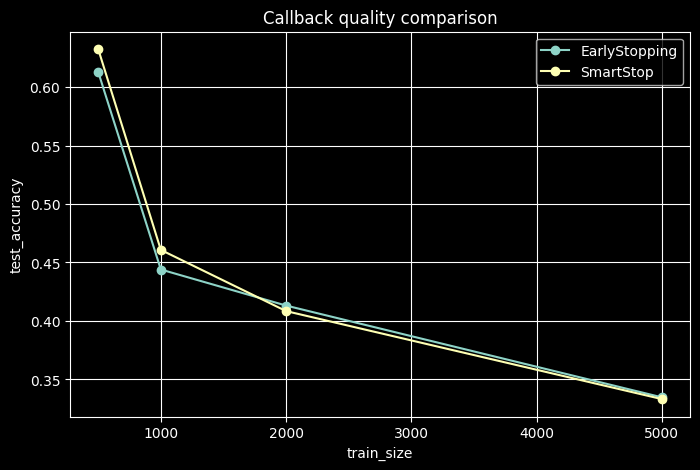

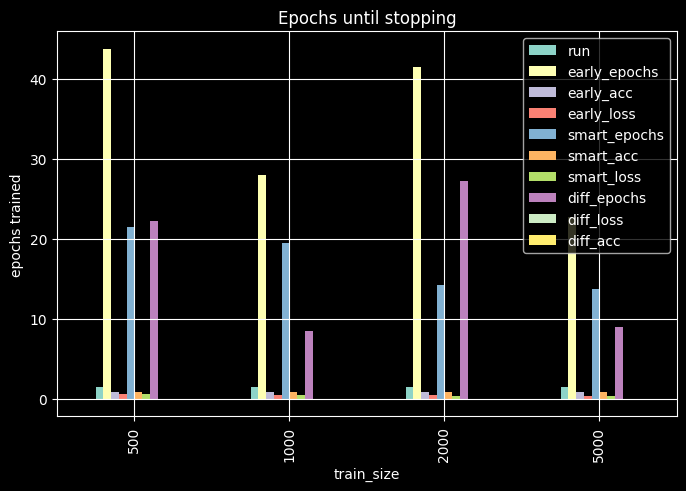

In [31]:
df['diff_epochs'] = df['early_epochs'] - df['smart_epochs']
df['diff_loss'] = df['early_loss'] - df['smart_loss']
df['diff_acc'] = df['early_acc'] - df['smart_acc']
summary = df.groupby("train_size").mean()

print(summary[[
    "early_acc",
    "smart_acc",
    "early_loss",
    "smart_loss",
    "early_epochs",
    "smart_epochs", "diff_epochs", 'diff_acc', 'diff_loss'
]])
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(summary.index, summary["early_loss"], marker="o", label="EarlyStopping")
plt.plot(summary.index, summary["smart_loss"], marker="o", label="SmartStop")

plt.xlabel("train_size")
plt.ylabel("test_accuracy")
plt.title("Callback quality comparison")

plt.legend()
plt.grid()

plt.show()
import matplotlib.pyplot as plt

summary.plot(kind="bar", figsize=(8, 5))

plt.ylabel("epochs trained")
plt.title("Epochs until stopping")
plt.grid()

plt.show()

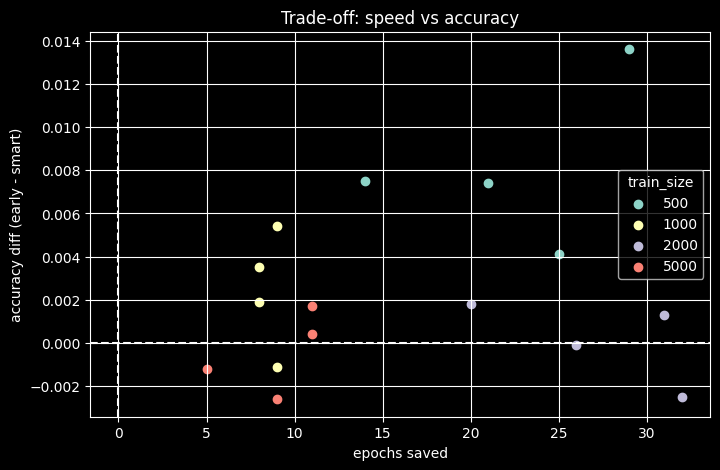

In [40]:
plt.figure(figsize=(8, 5))

for size in sizes:
    subset = df[df["train_size"] == size]

    plt.scatter(
        subset["diff_epochs"],
        subset["diff_acc"],
        label=f"{size}"
    )

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("epochs saved")
plt.ylabel("accuracy diff (early - smart)")
plt.title("Trade-off: speed vs accuracy")
plt.legend(title="train_size")
plt.grid()

plt.show()


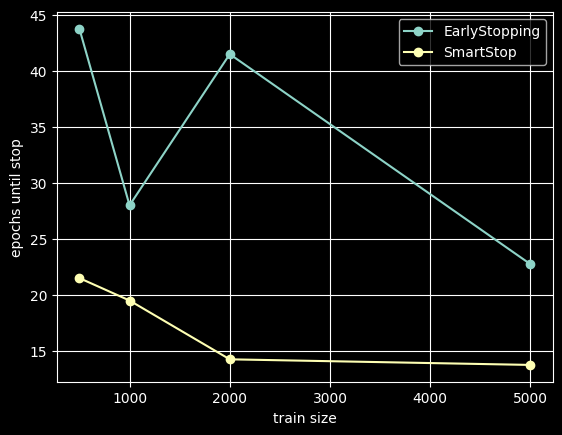

In [32]:
import matplotlib.pyplot as plt

plt.plot(summary.index, summary["early_epochs"], marker="o", label="EarlyStopping")
plt.plot(summary.index, summary["smart_epochs"], marker="o", label="SmartStop")

plt.xlabel("train size")
plt.ylabel("epochs until stop")

plt.legend()
plt.grid()

plt.show()